In [1]:
import torch 
from torch import nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
device = 'mps' if torch.mps.is_available() else 'cpu'
torch.mps.manual_seed(1234)
torch.manual_seed(1234)

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()
scaler = StandardScaler()


X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = torch.from_numpy(X_train_scaled).type(torch.float)
X_test_scaled = torch.from_numpy(X_test_scaled).type(torch.float)

y_train = torch.from_numpy(y_train).type(torch.long)
y_test = torch.from_numpy(y_test).type(torch.long)

In [3]:
class WineModel0(nn.Module):
    def __init__(self, input_features=13, output_features=3, hidden_units=20):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    
    def forward(self, x):
        return self.network(x)
    
model0 = WineModel0().to(device)

In [4]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.1)

In [5]:
def accuracy_function(y_true, y_pred):
    y_pred = y_pred.long()
    y_true = y_true.long()

    return (y_pred == y_true).float().mean().item() * 100

In [6]:
X_train_scaled, y_train = X_train_scaled.to(device), y_train.to(device)
X_test_scaled, y_test = X_test_scaled.to(device), y_test.to(device)

In [7]:
num_epochs = 100

test_acc, train_acc, epochs, test_losses, train_losses = [], [], [], [], []

for i in range(num_epochs):
    model0.train()
    y_logits = model0(X_train_scaled)
    y_softmax = torch.softmax(y_logits, dim=1).argmax(dim=1)
    train_accuracy = accuracy_function(y_pred=y_softmax, y_true=y_train)
    train_loss = loss_function(y_logits, y_train)
    
    train_losses.append(train_loss)
    train_acc.append(train_accuracy)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    with torch.inference_mode():
        model0.eval()

        y_logits_test = model0(X_test_scaled)
        y_softmax_test = torch.softmax(y_logits_test, dim=1).argmax(dim=1)
        test_accuracy = accuracy_function(y_pred=y_softmax_test, y_true=y_test)
        test_loss = loss_function(y_logits_test, y_test)
        
        test_losses.append(test_loss)
        test_acc.append(test_accuracy)
        epochs.append(i)
        if i % 10 == 0:
            print(f'Epoch: {i} | Train Acc: {train_accuracy: .2f} | Test Acc: {test_accuracy: .2f}')


Epoch: 0 | Train Acc:  31.69 | Test Acc:  38.89
Epoch: 10 | Train Acc:  73.94 | Test Acc:  77.78
Epoch: 20 | Train Acc:  88.73 | Test Acc:  88.89
Epoch: 30 | Train Acc:  93.66 | Test Acc:  94.44
Epoch: 40 | Train Acc:  95.77 | Test Acc:  97.22
Epoch: 50 | Train Acc:  96.48 | Test Acc:  97.22
Epoch: 60 | Train Acc:  98.59 | Test Acc:  100.00
Epoch: 70 | Train Acc:  98.59 | Test Acc:  100.00
Epoch: 80 | Train Acc:  98.59 | Test Acc:  100.00
Epoch: 90 | Train Acc:  99.30 | Test Acc:  100.00


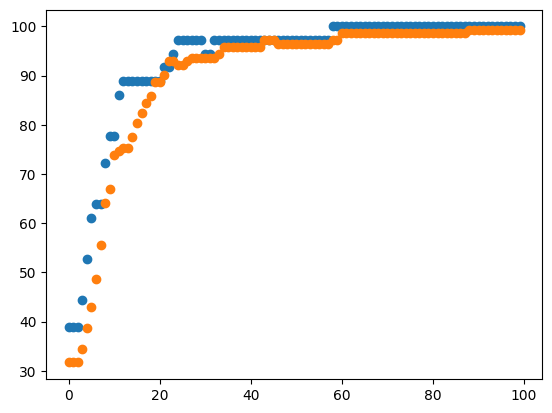

In [8]:
plt.scatter(epochs, test_acc)
plt.scatter(epochs, train_acc)
plt.show()